<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
">
    <img 
        src="https://raw.githubusercontent.com/sarasadatnasr/Machine_Learning_Final_Project/728689a356aa43073d6552462b8ba6ab8aca9218/Logo/ut-logo.png"
        alt="University Logo"
        style="height: 120px;"
    >
    <div style="
        text-align: center;
        font-family: 'Segoe UI', Arial, sans-serif;
        color: #222;
        line-height: 1.4;
    ">
        <h1 style="margin: 0; font-size: 32px; color: #2e98c6;">Machine Learning - Final Project</h1>
        <h3 style="margin: 6px 0 12px; font-weight: 500; color: #555;">Evaluation</h3>
        <p style="margin: 0; font-size: 15px;">
            <strong>Sara Sadat Nasr Azadani</strong> ·
            <strong>Alireza Farshi</strong> ·
            <strong>Saeid Rezaie</strong>
        </p>
    </div>
    <img 
        src="https://raw.githubusercontent.com/sarasadatnasr/Machine_Learning_Final_Project/7dab869a805ff296327c1fdcbc6954e3478073e7/Logo/co-w-9.png"
        alt="Faculty Logo"
        style="height: 120px;"
    >
</div>

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
📚Import Libraries
</div>

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import warnings

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🎨 Set Environments theme
</div>

In [53]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
📁 Load Results of Clustering & Classification
</div>

In [54]:
def load_results():
    results = {}
    # Load classification
    cls_dir = './Classification_Results'
    if os.path.exists(cls_dir):
        # Load metrics
        metrics_path = os.path.join(cls_dir, 'classification_metrics.csv')
        if os.path.exists(metrics_path):
            results['cls_metrics'] = pd.read_csv(metrics_path, index_col=0)
        
        # Load details
        json_path = os.path.join(cls_dir, 'classification_results.json')
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                results['cls_details'] = json.load(f)
    
    # Load clustering (latest)
    cluster_dirs = [d for d in os.listdir('.') if d.startswith('clustering_results_')]
    if cluster_dirs:
        latest_dir = sorted(cluster_dirs)[-1]
        json_path = os.path.join(latest_dir, 'clustering_results.json')
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                results['clu_details'] = json.load(f)
        
        # Load metrics
        metrics_path = os.path.join(latest_dir, 'clustering_metrics.csv')
        if os.path.exists(metrics_path):
            results['clu_metrics'] = pd.read_csv(metrics_path, index_col=0)
    
    return results

# Load data
results = load_results()
if 'cls_metrics' in results:
    print(f"Classification models: {len(results['cls_metrics'])}")
if 'clu_metrics' in results:
    print(f"Clustering algorithms: {len(results['clu_metrics'])}")


Classification models: 7
Clustering algorithms: 10


<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🏆 Extract best models
</div>

In [55]:
summary = {}

if 'cls_metrics' in results:
    best_cls_idx = results['cls_metrics']['Test Accuracy'].idxmax()
    best_cls = results['cls_metrics'].loc[best_cls_idx]
    summary['classification'] = {
        'best_model': best_cls_idx,
        'test_accuracy': float(best_cls['Test Accuracy']),
        'train_accuracy': float(best_cls['Train Accuracy']),
        'generalization_gap': float(best_cls['Generalization Gap']),
        'cv_mean': float(best_cls['CV Mean']),
        'cv_std': float(best_cls['CV Std']),
        'training_time': float(best_cls['Training Time'])
    }

if 'clu_details' in results:
    best_clu = results['clu_details']['best_algorithm']
    clu_metrics = results['clu_details']['metrics'][best_clu]
    summary['clustering'] = {
        'best_algorithm': best_clu,
        'clusters_found': int(clu_metrics['n_clusters_found']),
        'silhouette_score': float(clu_metrics['silhouette_score']),
        'calinski_harabasz': float(clu_metrics['calinski_harabasz']),
        'davies_bouldin': float(clu_metrics['davies_bouldin']),
        'cluster_purity': float(results['clu_details']['purity_scores'][best_clu])
    }

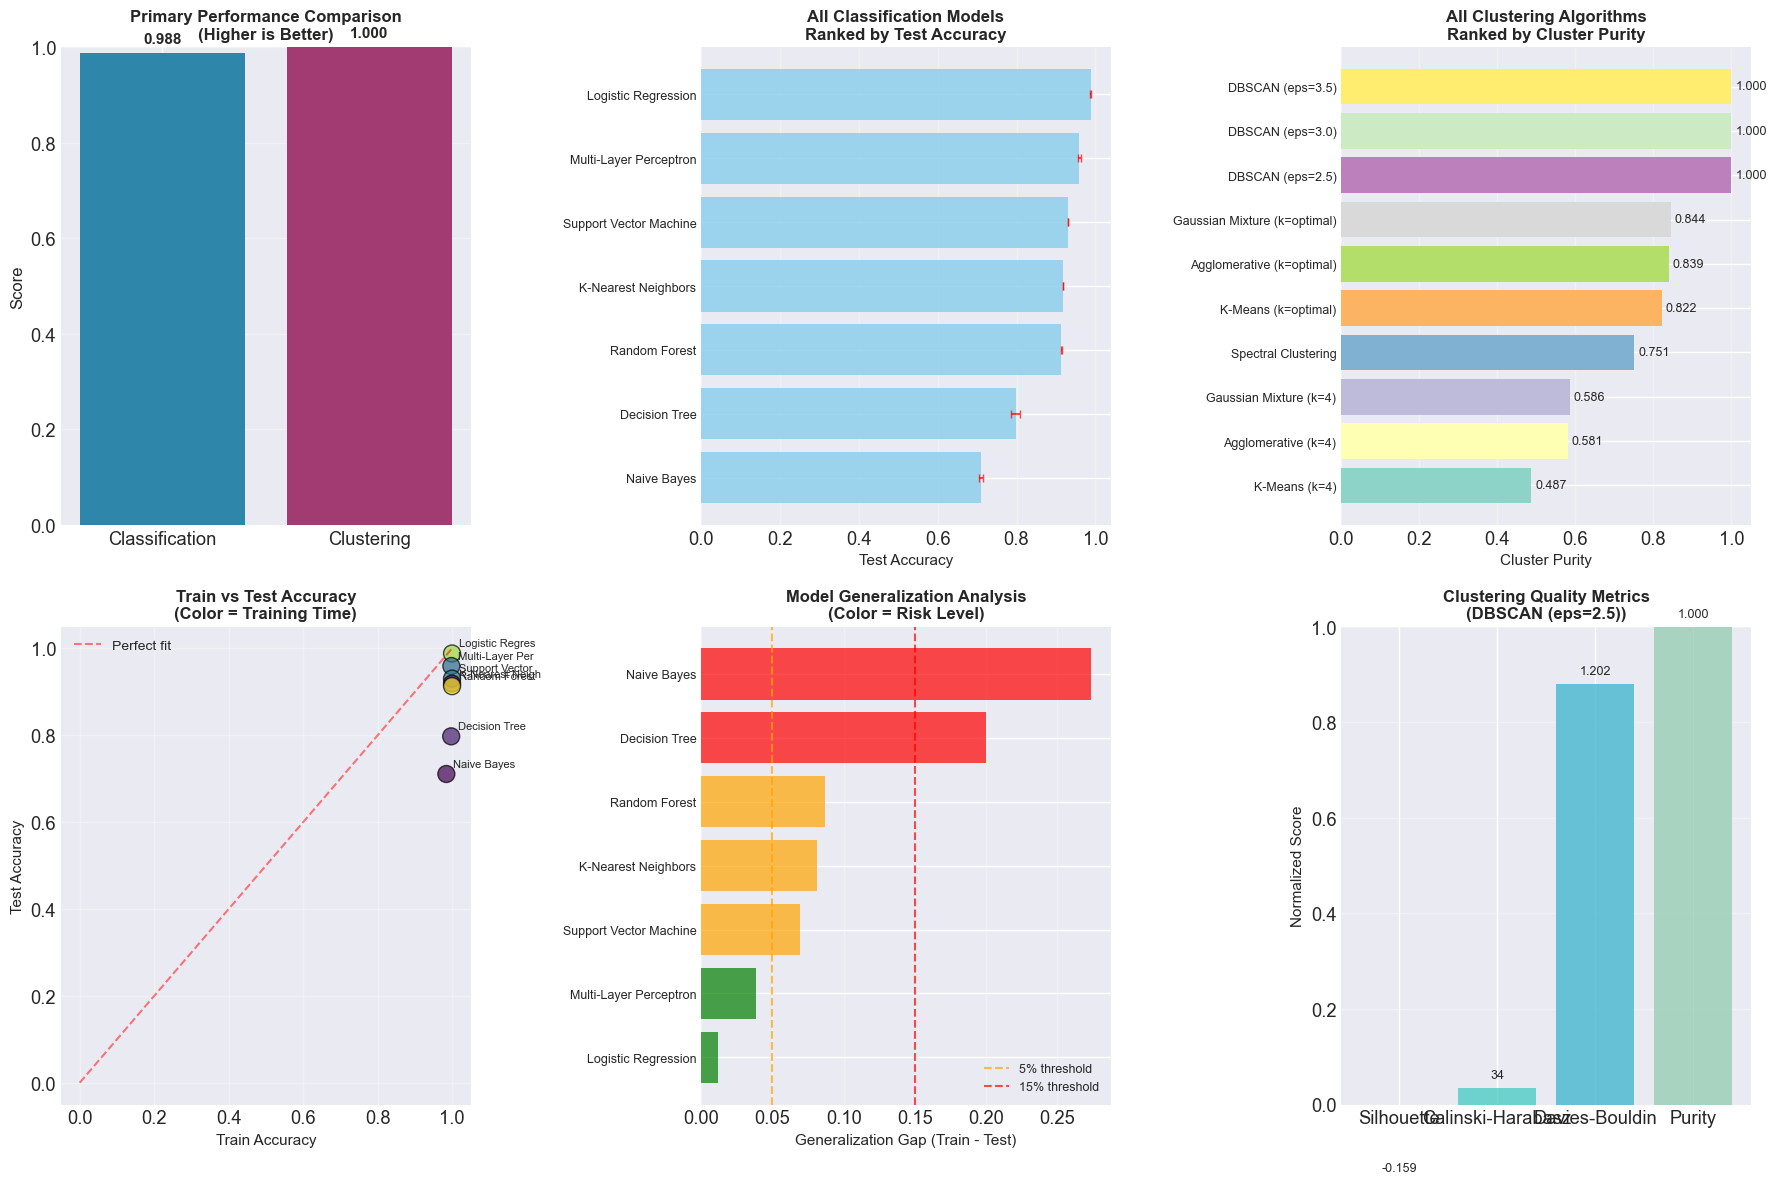

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1.1 Test Accuracy vs Cluster Purity
if 'classification' in summary and 'clustering' in summary:
    models = ['Classification', 'Clustering']
    scores = [summary['classification']['test_accuracy'], 
              summary['clustering']['cluster_purity']]
    
    bars1 = axes[0, 0].bar(models, scores, color=['#2E86AB', '#A23B72'])
    axes[0, 0].set_ylabel('Score', fontsize=12)
    axes[0, 0].set_title('Primary Performance Comparison\n(Higher is Better)', 
                        fontweight='bold', fontsize=12)
    axes[0, 0].set_ylim([0, 1])
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    for bar, score in zip(bars1, scores):
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                       f'{score:.3f}', ha='center', fontsize=11, fontweight='bold')

# 1.2 All Classification Models Performance
if 'cls_metrics' in results:
    df = results['cls_metrics'].sort_values('Test Accuracy', ascending=True)
    y_pos = np.arange(len(df))
    
    bars2 = axes[0, 1].barh(y_pos, df['Test Accuracy'], color='skyblue', alpha=0.8)
    axes[0, 1].set_yticks(y_pos)
    axes[0, 1].set_yticklabels(df.index, fontsize=9)
    axes[0, 1].set_xlabel('Test Accuracy', fontsize=11)
    axes[0, 1].set_title('All Classification Models\nRanked by Test Accuracy', 
                        fontweight='bold', fontsize=12)
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # Add CV error bars
    axes[0, 1].errorbar(df['Test Accuracy'], y_pos, 
                        xerr=df['CV Std'], fmt='none', 
                        color='red', alpha=0.7, capsize=3)

# 1.3 All Clustering Algorithms Performance
if 'clu_metrics' in results:
    df = results['clu_metrics'].sort_values('cluster_purity', ascending=True)
    y_pos = np.arange(len(df))
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(df)))
    bars3 = axes[0, 2].barh(y_pos, df['cluster_purity'], color=colors)
    axes[0, 2].set_yticks(y_pos)
    axes[0, 2].set_yticklabels(df.index, fontsize=9)
    axes[0, 2].set_xlabel('Cluster Purity', fontsize=11)
    axes[0, 2].set_title('All Clustering Algorithms\nRanked by Cluster Purity', 
                        fontweight='bold', fontsize=12)
    axes[0, 2].grid(True, alpha=0.3, axis='x')
    
    for i, (idx, row) in enumerate(df.iterrows()):
        axes[0, 2].text(row['cluster_purity'] + 0.01, i, 
                       f'{row["cluster_purity"]:.3f}', 
                       va='center', fontsize=9)

# 1.4 Training vs Test Performance (Classification)
if 'cls_metrics' in results:
    df = results['cls_metrics']
    axes[1, 0].scatter(df['Train Accuracy'], df['Test Accuracy'], 
                      s=150, alpha=0.7, c=df['Training Time'], 
                      cmap='viridis', edgecolors='black')
    
    # Add diagonal line
    axes[1, 0].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect fit')
    
    # Annotate points
    for idx, row in df.iterrows():
        axes[1, 0].annotate(idx[:15], (row['Train Accuracy'], row['Test Accuracy']),
                           xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    axes[1, 0].set_xlabel('Train Accuracy', fontsize=11)
    axes[1, 0].set_ylabel('Test Accuracy', fontsize=11)
    axes[1, 0].set_title('Train vs Test Accuracy\n(Color = Training Time)', 
                        fontweight='bold', fontsize=12)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)

# 1.5 Generalization Gap Analysis
if 'cls_metrics' in results:
    df = results['cls_metrics']
    gaps = df['Generalization Gap']
    
    # Color code by gap size
    colors = []
    for gap in gaps:
        if gap > 0.15:
            colors.append('red')
        elif gap > 0.05:
            colors.append('orange')
        else:
            colors.append('green')
    
    y_pos = np.arange(len(gaps))
    bars5 = axes[1, 1].barh(y_pos, gaps, color=colors, alpha=0.7)
    axes[1, 1].set_yticks(y_pos)
    axes[1, 1].set_yticklabels(df.index, fontsize=9)
    axes[1, 1].set_xlabel('Generalization Gap (Train - Test)', fontsize=11)
    axes[1, 1].set_title('Model Generalization Analysis\n(Color = Risk Level)', 
                        fontweight='bold', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    # Add threshold lines
    axes[1, 1].axvline(x=0.05, color='orange', linestyle='--', alpha=0.7, label='5% threshold')
    axes[1, 1].axvline(x=0.15, color='red', linestyle='--', alpha=0.7, label='15% threshold')
    axes[1, 1].legend(fontsize=9)

# 1.6 Clustering Quality Metrics
if 'clu_details' in results:
    best_clu = summary['clustering']['best_algorithm']
    clu_metrics = results['clu_details']['metrics'][best_clu]
    
    metrics = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'Purity']
    
    # Normalize for comparison (except Davies-Bouldin which is lower=better)
    silhouette_norm = clu_metrics['silhouette_score']
    calinski_norm = min(clu_metrics['calinski_harabasz'] / 1000, 1.0)  # Scale down
    davies_norm = 1 - min(clu_metrics['davies_bouldin'] / 10, 1.0)  # Invert
    purity_norm = clu_metrics.get('cluster_purity', 0)
    
    values = [silhouette_norm, calinski_norm, davies_norm, purity_norm]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    bars6 = axes[1, 2].bar(metrics, values, color=colors, alpha=0.8)
    axes[1, 2].set_ylabel('Normalized Score', fontsize=11)
    axes[1, 2].set_title(f'Clustering Quality Metrics\n({best_clu})', 
                        fontweight='bold', fontsize=12)
    axes[1, 2].set_ylim([0, 1])
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    
    # Add actual values
    actual_values = [
        f"{clu_metrics['silhouette_score']:.3f}",
        f"{clu_metrics['calinski_harabasz']:.0f}",
        f"{clu_metrics['davies_bouldin']:.3f}",
        f"{clu_metrics.get('cluster_purity', 0):.3f}"
    ]
    
    for bar, actual in zip(bars6, actual_values):
        axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                       actual, ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('./Evaluation/performance_comparison_matrix.png', dpi=300, bbox_inches='tight')
plt.show()



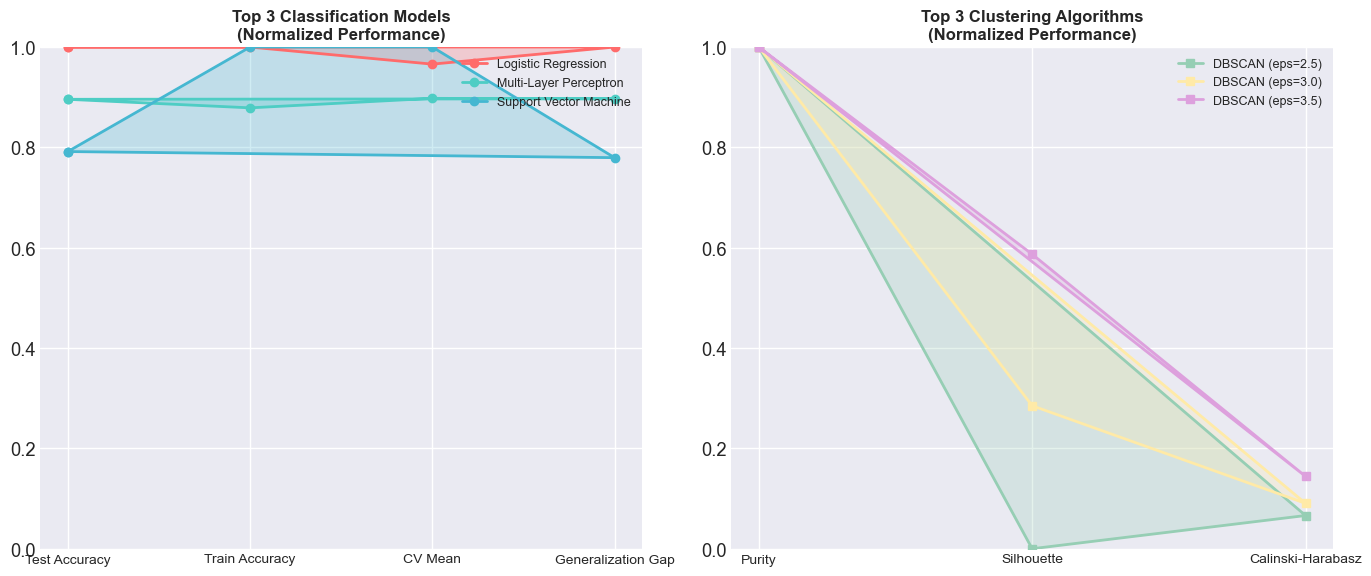

In [57]:
# Radar Chart Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2.1 Classification Models Radar
if 'cls_metrics' in results:
    df = results['cls_metrics']
    
    # Select metrics for radar
    radar_metrics = ['Test Accuracy', 'Train Accuracy', 'CV Mean', 'Generalization Gap']
    radar_df = df[radar_metrics].copy()
    
    # Normalize (except generalization gap which we want low)
    for metric in radar_metrics:
        if metric == 'Generalization Gap':
            radar_df[metric] = 1 - radar_df[metric]  # Invert so higher is better
        radar_df[metric] = (radar_df[metric] - radar_df[metric].min()) / (radar_df[metric].max() - radar_df[metric].min())
    
    # Plot top 3 models
    top_models = df.nlargest(3, 'Test Accuracy').index
    angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    ax = axes[0]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    for idx, model in enumerate(top_models):
        values = radar_df.loc[model].values.tolist()
        values += values[:1]  # Close the loop
        
        ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[idx])
        ax.fill(angles, values, alpha=0.25, color=colors[idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, fontsize=10)
    ax.set_ylim([0, 1])
    ax.set_title('Top 3 Classification Models\n(Normalized Performance)', 
                fontweight='bold', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True)

# 2.2 Clustering Algorithms Radar
if 'clu_metrics' in results:
    df = results['clu_metrics']
    
    # Select metrics for radar
    radar_metrics = ['cluster_purity', 'silhouette_score', 'calinski_harabasz']
    radar_df = df[radar_metrics].copy()
    
    # Normalize
    for metric in radar_metrics:
        radar_df[metric] = (radar_df[metric] - radar_df[metric].min()) / (radar_df[metric].max() - radar_df[metric].min())
    
    # Plot top 3 algorithms
    top_algorithms = df.nlargest(3, 'cluster_purity').index
    angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    ax = axes[1]
    colors = ['#96CEB4', '#FFEAA7', '#DDA0DD']
    
    for idx, algorithm in enumerate(top_algorithms):
        values = radar_df.loc[algorithm].values.tolist()
        values += values[:1]  # Close the loop
        
        ax.plot(angles, values, 's-', linewidth=2, label=algorithm, color=colors[idx])
        ax.fill(angles, values, alpha=0.25, color=colors[idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Purity', 'Silhouette', 'Calinski-Harabasz'], fontsize=10)
    ax.set_ylim([0, 1])
    ax.set_title('Top 3 Clustering Algorithms\n(Normalized Performance)', 
                fontweight='bold', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.savefig('./Evaluation/radar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



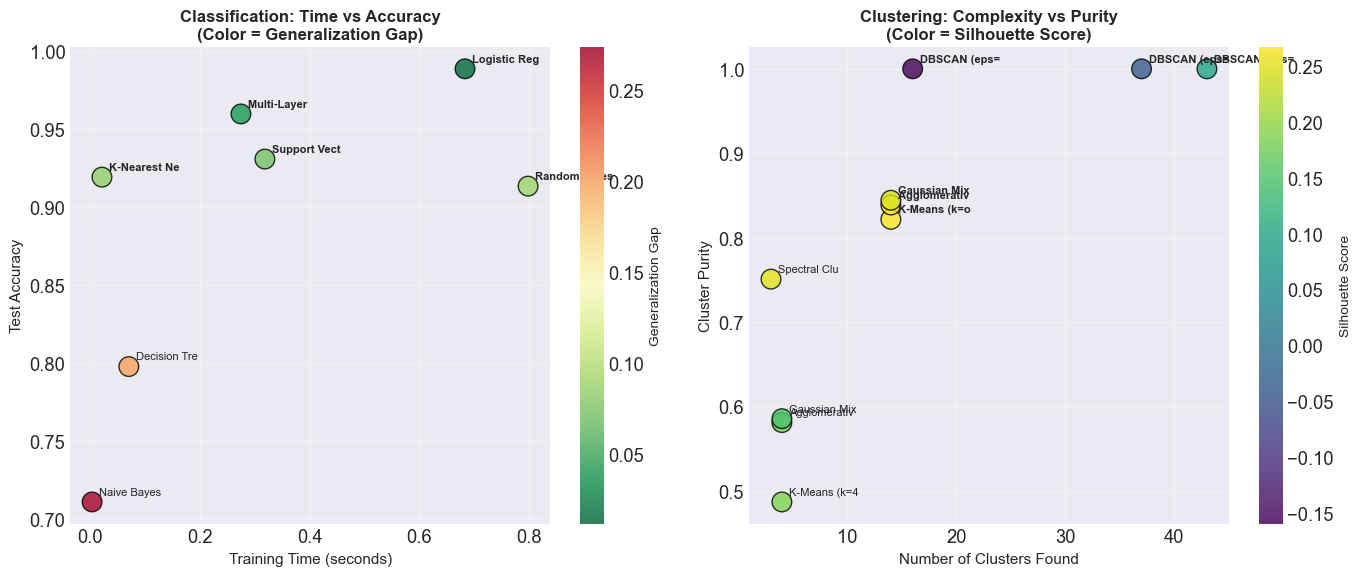

In [58]:
# PLOT 3: Time vs Performance Trade-off
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 3.1 Classification: Time vs Accuracy
if 'cls_metrics' in results:
    df = results['cls_metrics']
    
    scatter = axes[0].scatter(df['Training Time'], df['Test Accuracy'], 
                             s=200, c=df['Generalization Gap'], 
                             cmap='RdYlGn_r', alpha=0.8, 
                             edgecolors='black', linewidth=1)
    
    # Annotate points
    for idx, row in df.iterrows():
        axes[0].annotate(idx[:12], (row['Training Time'], row['Test Accuracy']),
                        xytext=(5, 5), textcoords='offset points', 
                        fontsize=8, fontweight='bold' if row['Test Accuracy'] > 0.8 else 'normal')
    
    axes[0].set_xlabel('Training Time (seconds)', fontsize=11)
    axes[0].set_ylabel('Test Accuracy', fontsize=11)
    axes[0].set_title('Classification: Time vs Accuracy\n(Color = Generalization Gap)', 
                     fontweight='bold', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=axes[0])
    cbar.set_label('Generalization Gap', fontsize=10)

# 3.2 Clustering: Performance vs Complexity
if 'clu_metrics' in results and 'clu_details' in results:
    df = results['clu_metrics']
    
    # Get cluster counts
    cluster_counts = []
    for algo in df.index:
        if algo in results['clu_details']['metrics']:
            cluster_counts.append(results['clu_details']['metrics'][algo]['n_clusters_found'])
        else:
            cluster_counts.append(4)  # Default
    
    df['cluster_count'] = cluster_counts
    
    scatter = axes[1].scatter(df['cluster_count'], df['cluster_purity'], 
                             s=200, c=df['silhouette_score'], 
                             cmap='viridis', alpha=0.8, 
                             edgecolors='black', linewidth=1)
    
    # Annotate points
    for idx, row in df.iterrows():
        axes[1].annotate(idx[:12], (row['cluster_count'], row['cluster_purity']),
                        xytext=(5, 5), textcoords='offset points', 
                        fontsize=8, fontweight='bold' if row['cluster_purity'] > 0.8 else 'normal')
    
    axes[1].set_xlabel('Number of Clusters Found', fontsize=11)
    axes[1].set_ylabel('Cluster Purity', fontsize=11)
    axes[1].set_title('Clustering: Complexity vs Purity\n(Color = Silhouette Score)', 
                     fontweight='bold', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=axes[1])
    cbar.set_label('Silhouette Score', fontsize=10)

plt.tight_layout()
plt.savefig('./Evaluation/time_performance_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()


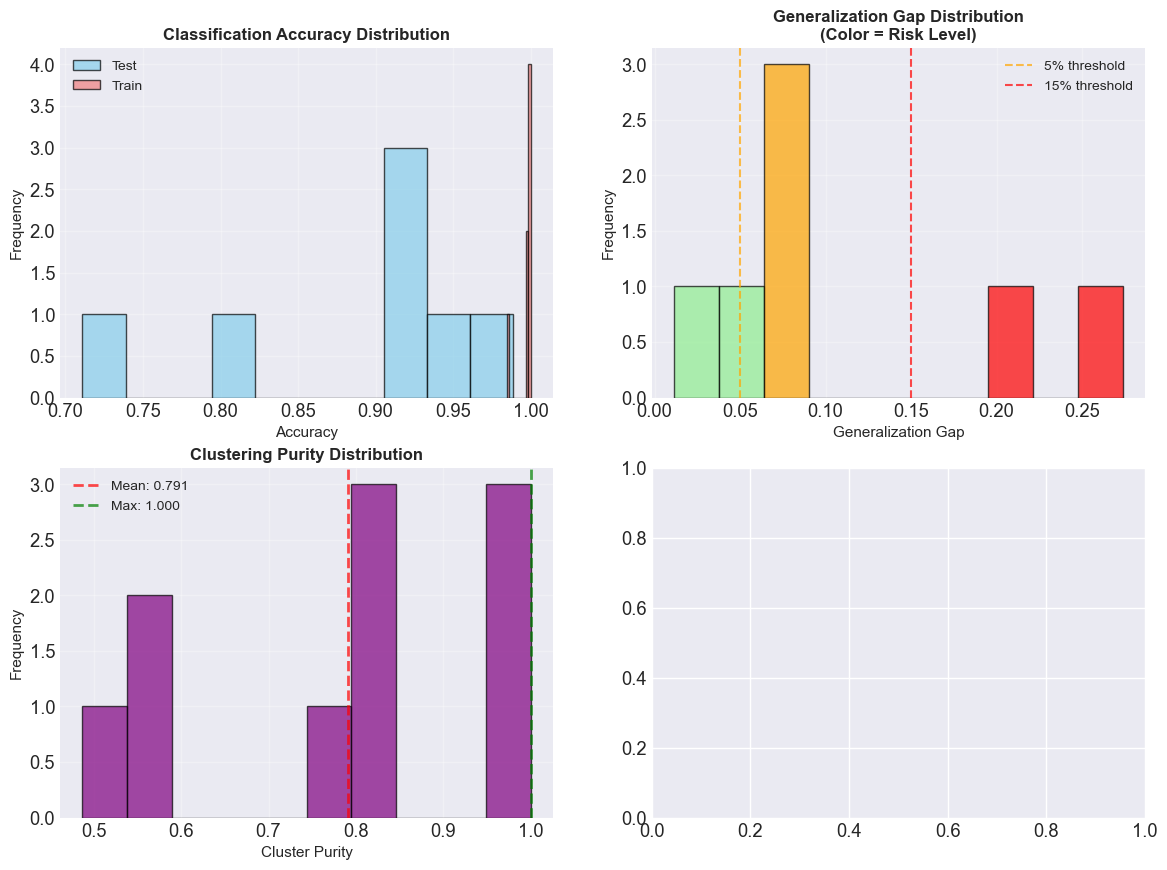

In [59]:

# PLOT 4: Side-by-side Distribution Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4.1 Classification Accuracy Distribution
if 'cls_metrics' in results:
    df = results['cls_metrics']
    
    # Test vs Train accuracy distribution
    axes[0, 0].hist(df['Test Accuracy'], bins=10, alpha=0.7, color='skyblue', 
                   label='Test', edgecolor='black')
    axes[0, 0].hist(df['Train Accuracy'], bins=10, alpha=0.7, color='lightcoral', 
                   label='Train', edgecolor='black')
    axes[0, 0].set_xlabel('Accuracy', fontsize=11)
    axes[0, 0].set_ylabel('Frequency', fontsize=11)
    axes[0, 0].set_title('Classification Accuracy Distribution', 
                        fontweight='bold', fontsize=12)
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)

# 4.2 Generalization Gap Distribution
if 'cls_metrics' in results:
    gaps = df['Generalization Gap']
    
    n, bins, patches = axes[0, 1].hist(gaps, bins=10, alpha=0.7, 
                                       color='lightgreen', edgecolor='black')
    
    # Color code by gap size
    for i, patch in enumerate(patches):
        if bins[i] > 0.15:
            patch.set_facecolor('red')
        elif bins[i] > 0.05:
            patch.set_facecolor('orange')
    
    axes[0, 1].axvline(x=0.05, color='orange', linestyle='--', alpha=0.7, label='5% threshold')
    axes[0, 1].axvline(x=0.15, color='red', linestyle='--', alpha=0.7, label='15% threshold')
    axes[0, 1].set_xlabel('Generalization Gap', fontsize=11)
    axes[0, 1].set_ylabel('Frequency', fontsize=11)
    axes[0, 1].set_title('Generalization Gap Distribution\n(Color = Risk Level)', 
                        fontweight='bold', fontsize=12)
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)

# 4.3 Clustering Purity Distribution
if 'clu_metrics' in results:
    purities = results['clu_metrics']['cluster_purity']
    
    axes[1, 0].hist(purities, bins=10, alpha=0.7, color='purple', 
                   edgecolor='black')
    axes[1, 0].axvline(x=purities.mean(), color='red', linestyle='--', 
                      alpha=0.7, linewidth=2, label=f'Mean: {purities.mean():.3f}')
    axes[1, 0].axvline(x=purities.max(), color='green', linestyle='--', 
                      alpha=0.7, linewidth=2, label=f'Max: {purities.max():.3f}')
    axes[1, 0].set_xlabel('Cluster Purity', fontsize=11)
    axes[1, 0].set_ylabel('Frequency', fontsize=11)
    axes[1, 0].set_title('Clustering Purity Distribution', 
                        fontweight='bold', fontsize=12)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)




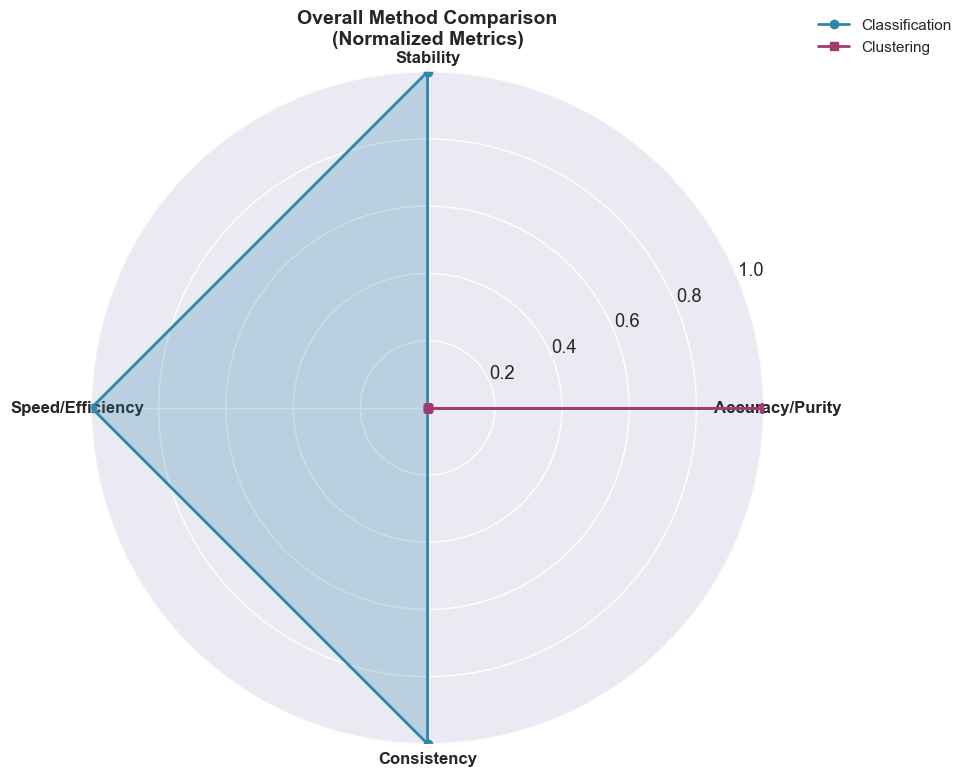

In [60]:
# PLOT 5: Method Comparison Summary
fig = plt.figure(figsize=(16, 8))

if 'classification' in summary and 'clustering' in summary:
    # Create comparison metrics
    comparison_data = {
        'Accuracy/Purity': [summary['classification']['test_accuracy'], 
                          summary['clustering']['cluster_purity']],
        'Stability': [1 - summary['classification']['generalization_gap'],  # Higher is better
                     summary['clustering']['silhouette_score']],
        'Speed/Efficiency': [1 / (summary['classification']['training_time'] + 0.1),  # Higher is better
                           summary['clustering']['calinski_harabasz'] / 1000],  # Scale down
        'Consistency': [1 - summary['classification']['cv_std'],  # Higher is better
                       summary['clustering']['davies_bouldin']]  # Lower is better, will invert
    }
    
    # Invert Davies-Bouldin (lower is better)
    comparison_data['Consistency'][1] = 1 - min(comparison_data['Consistency'][1] / 10, 1)
    
    # Normalize all values to 0-1 range
    for metric in comparison_data:
        min_val = min(comparison_data[metric])
        max_val = max(comparison_data[metric])
        if max_val > min_val:
            comparison_data[metric] = [(v - min_val) / (max_val - min_val) for v in comparison_data[metric]]
    
    categories = list(comparison_data.keys())
    N = len(categories)
    
    # Angles for radar chart
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the loop
    
    # Values for each method
    cls_values = [comparison_data[cat][0] for cat in categories]
    cls_values += cls_values[:1]
    
    clu_values = [comparison_data[cat][1] for cat in categories]
    clu_values += clu_values[:1]
    
    ax = plt.subplot(111, polar=True)
    
    # Plot lines
    ax.plot(angles, cls_values, 'o-', linewidth=2, label='Classification', color='#2E86AB')
    ax.fill(angles, cls_values, alpha=0.25, color='#2E86AB')
    
    ax.plot(angles, clu_values, 's-', linewidth=2, label='Clustering', color='#A23B72')
    ax.fill(angles, clu_values, alpha=0.25, color='#A23B72')
    
    # Set labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    
    # Add legend
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    
    # Add title
    plt.title('Overall Method Comparison\n(Normalized Metrics)', 
             fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('./Evaluation/method_comparison_summary.png', dpi=300, bbox_inches='tight')
    plt.show()


<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🔍 comprehensive report
</div>

In [62]:
if 'classification' in summary:
    print(f"\n CLASSIFICATION SUMMARY:")
    print(f"   Best Model: {summary['classification']['best_model']}")
    print(f"   Test Accuracy: {summary['classification']['test_accuracy']:.3f}")
    print(f"   CV Accuracy: {summary['classification']['cv_mean']:.3f} (±{summary['classification']['cv_std']:.3f})")
    print(f"   Generalization Gap: {summary['classification']['generalization_gap']:.3f}")
    print(f"   Training Time: {summary['classification']['training_time']:.2f}s")

if 'clustering' in summary:
    print(f"\n CLUSTERING SUMMARY:")
    print(f"   Best Algorithm: {summary['clustering']['best_algorithm']}")
    print(f"   Cluster Purity: {summary['clustering']['cluster_purity']:.3f}")
    print(f"   Clusters Found: {summary['clustering']['clusters_found']}")
    print(f"   Silhouette Score: {summary['clustering']['silhouette_score']:.3f}")



 CLASSIFICATION SUMMARY:
   Best Model: Logistic Regression
   Test Accuracy: 0.988
   CV Accuracy: 0.999 (±0.001)
   Generalization Gap: 0.012
   Training Time: 0.68s

 CLUSTERING SUMMARY:
   Best Algorithm: DBSCAN (eps=2.5)
   Cluster Purity: 1.000
   Clusters Found: 16
   Silhouette Score: -0.159
